<a href="https://colab.research.google.com/github/pawan-rai02/pytorch/blob/main/07_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [30]:
torch.manual_seed(42)

In [31]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


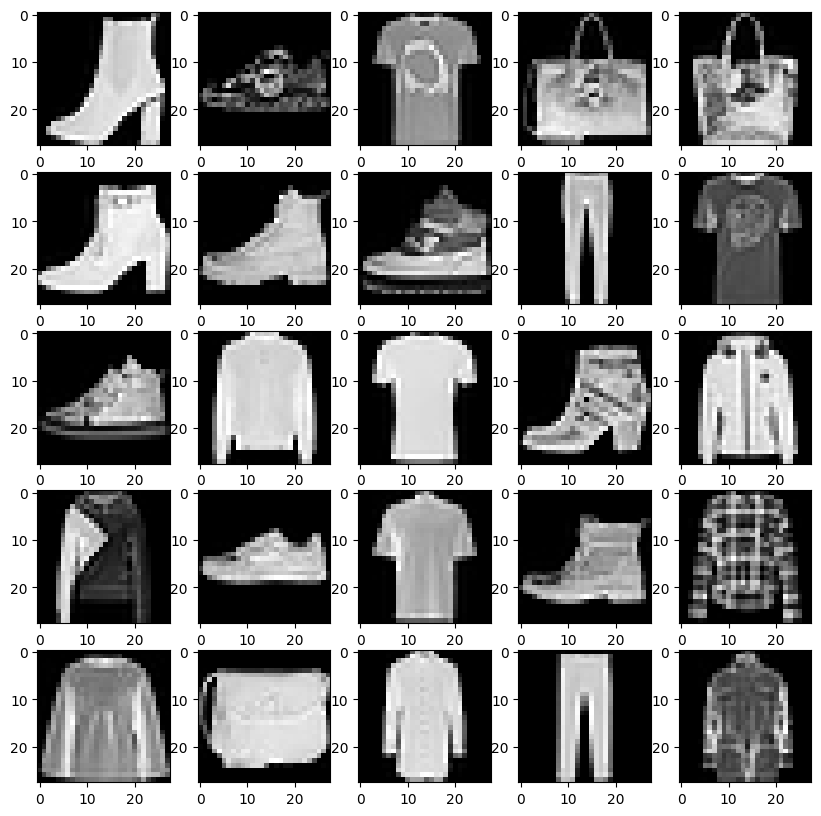

In [32]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(df.iloc[i, 1:].values.reshape(28, 28), cmap='gray')

In [33]:
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [35]:
x_train = x_train / 255.0
x_test  = x_test / 255.0

In [36]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels   = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]


In [37]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset  = CustomDataset(x_test, y_test)

In [38]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader  = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [39]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)

In [40]:
epochs = 100
lr = 0.1

In [41]:
model = MyNN(x_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = lr)

In [42]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update weights
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  print(f'Epoch: {epoch+1}, Avg Loss: {total_epoch_loss/len(train_loader)}')


Epoch: 1, Avg Loss: 1.3216368440786999
Epoch: 2, Avg Loss: 0.7793365436792373
Epoch: 3, Avg Loss: 0.6427524652083715
Epoch: 4, Avg Loss: 0.5751657336950302
Epoch: 5, Avg Loss: 0.528180201848348
Epoch: 6, Avg Loss: 0.49528750121593473
Epoch: 7, Avg Loss: 0.4602432996034622
Epoch: 8, Avg Loss: 0.4359459094206492
Epoch: 9, Avg Loss: 0.41829214423894884
Epoch: 10, Avg Loss: 0.3984092291692893
Epoch: 11, Avg Loss: 0.3850264506538709
Epoch: 12, Avg Loss: 0.3722685620188713
Epoch: 13, Avg Loss: 0.3477362078428268
Epoch: 14, Avg Loss: 0.3467242218057315
Epoch: 15, Avg Loss: 0.3138812760512034
Epoch: 16, Avg Loss: 0.3126461291313171
Epoch: 17, Avg Loss: 0.29552092105150224
Epoch: 18, Avg Loss: 0.2857150869568189
Epoch: 19, Avg Loss: 0.27084775785605114
Epoch: 20, Avg Loss: 0.26237100958824155
Epoch: 21, Avg Loss: 0.25756089876095456
Epoch: 22, Avg Loss: 0.24232648963729542
Epoch: 23, Avg Loss: 0.23957946779827277
Epoch: 24, Avg Loss: 0.2261324493587017
Epoch: 25, Avg Loss: 0.2233684351791938
Ep

In [43]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [45]:
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data, 1)
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

print(f'Accuracy: {100 * correct / total}')

Accuracy: 83.25
